In [ ]:
# base_financeiro

import pandas as pd
import numpy as np

caminho_completo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_financeiro.csv'

df = pd.read_csv(caminho_completo) 

colunas_days = [col for col in df.columns if 'DAYS' in col]

df[colunas_days] = df[colunas_days].mask(df[colunas_days] > 0, np.nan)

print("--- Resultado após a limpeza ---")
print(df[['SK_ID_CURR'] + colunas_days].head())

caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_financeiro_limpa.csv'
df.to_csv(caminho_salvar, index=False)

print("\nPlanilha limpa salva com sucesso como 'base_financeiro_limpa.csv'!")

In [ ]:
# base_infos_pessoais

import pandas as pd
import numpy as np

caminho_completo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_infos_pessoais.csv'
df_novo = pd.read_csv(caminho_completo)

df_novo.loc[df_novo['DAYS_BIRTH'] >= 0, 'DAYS_BIRTH'] = np.nan

mask_single = df_novo['NAME_FAMILY_STATUS'] == 'Single / Not Married'
df_novo.loc[mask_single, 'CNT_CHILDREN'] = 0
df_novo.loc[mask_single, 'CNT_FAM_MEMBERS'] = 1 + df_novo.loc[mask_single, 'CNT_CHILDREN']

mask_married = df_novo['NAME_FAMILY_STATUS'].isin(['Married', 'Civil Marriage'])
df_novo.loc[mask_married, 'CNT_FAM_MEMBERS'] = 2 + df_novo.loc[mask_married, 'CNT_CHILDREN']

df_novo.loc[df_novo['DAYS_BIRTH'] >= -6574, 'DAYS_BIRTH'] = np.nan

mask_higher = (df_novo['NAME_EDUCATION_TYPE'] == 'Higher education') & (df_novo['DAYS_BIRTH'] > -7665)
df_novo.loc[mask_higher, 'DAYS_BIRTH'] = np.nan

colunas_verificacao = ['DAYS_BIRTH', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_EDUCATION_TYPE']
print("--- Amostra após a limpeza lógica ---")
print(df_novo[colunas_verificacao].head(10))

caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_infos_pessoais_limpa.csv'

df_novo.to_csv(caminho_salvar, index=False)

print("\nSucesso! Planilha limpa salva como 'base_infos_pessoais_limpa.csv'.")

In [ ]:
# base_regional
import pandas as pd
import numpy as np

# 1. CARREGANDO A PLANILHA REGIONAL
caminho_regional = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_regional.csv'
df_regional = pd.read_csv(caminho_regional)

# --------------------------------------------------------------------------------
# ETAPA 1: Colunas que devem estar entre 0 e 1 (Normalizadas)
# --------------------------------------------------------------------------------
colunas_0_1 = [
    'REGION_POPULATION_RELATIVE', 
    'APARTMENTS_AVG', 
    'YEARS_BEGINEXPLUATATION_AVG', 
    'ELEVATORS_AVG'
]

for col in colunas_0_1:
    # Se o valor for menor que 0 OU maior que 1, transformamos em NaN
    df_regional[col] = df_regional[col].mask((df_regional[col] < 0) | (df_regional[col] > 1), np.nan)

# --------------------------------------------------------------------------------
# ETAPA 2: Rating da Região (Deve ser entre 1 e 3)
# --------------------------------------------------------------------------------
col_rating = 'REGION_RATING_CLIENT_W_CITY'
# Se o rating for menor que 1 OU maior que 3, transformamos em NaN
df_regional[col_rating] = df_regional[col_rating].mask((df_regional[col_rating] < 1) | (df_regional[col_rating] > 3), np.nan)

# --------------------------------------------------------------------------------
# ETAPA 3: SALVANDO O RESULTADO
# --------------------------------------------------------------------------------
caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_regional_limpa.csv'
df_regional.to_csv(caminho_salvar, index=False)

# --- Verificação final no terminal ---
print("=== Relatório de Limpeza (Base Regional) ===")
print(f"Intervalo esperado 0-1:\n{df_regional[colunas_0_1].agg(['min', 'max'])}")
print(f"\nIntervalo esperado 1-3 em Rating:\nMin: {df_regional[col_rating].min()} | Max: {df_regional[col_rating].max()}")
print(f"\nArquivo salvo em: {caminho_salvar}")

In [ ]:
# base_scores
import pandas as pd
import numpy as np

# 1. CARREGANDO A BASE DE SCORES
path_scores = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_scores.csv'
df_scores = pd.read_csv(path_scores)

# --------------------------------------------------------------------------------
# ETAPA 1: Scores Externos (Devem estar entre 0 e 1)
# --------------------------------------------------------------------------------
cols_ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

for col in cols_ext:
    # Anula se for menor que 0 OU maior que 1
    df_scores[col] = df_scores[col].mask((df_scores[col] < 0) | (df_scores[col] > 1), np.nan)

# --------------------------------------------------------------------------------
# ETAPA 2: Mudança de Telefone (Deve ser < 0)
# --------------------------------------------------------------------------------
# Se for maior ou igual a 0, transformamos em NaN
df_scores['DAYS_LAST_PHONE_CHANGE'] = df_scores['DAYS_LAST_PHONE_CHANGE'].mask(df_scores['DAYS_LAST_PHONE_CHANGE'] >= 0, np.nan)

# --------------------------------------------------------------------------------
# ETAPA 3: SALVANDO O RESULTADO
# --------------------------------------------------------------------------------
caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/extracao_bases/bases_baixadas/base_scores_limpa.csv'
df_scores.to_csv(caminho_salvar, index=False)

print("Base de scores processada e salva com sucesso!")
print(df_scores[cols_ext + ['DAYS_LAST_PHONE_CHANGE']].head())

In [ ]:
# fazendo o merge
import pandas as pd

# 1. Definindo os caminhos das bases limpas
paths = [
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_bens_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_financeiro_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_infos_pessoais_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_regional_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_scores_limpa.csv',
    '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/base_target_limpa.csv'
]

# 2. Carregando a primeira base para iniciar o "esqueleto" do dataframe final
df_final = pd.read_csv(paths[0])

# 3. Loop para ler e juntar as outras 5 bases
for path in paths[1:]:
    df_proximo = pd.read_csv(path)
    
    # Fazemos o merge usando o SK_ID_CURR. 
    # O how='left' garante que manteremos todos os IDs da base principal.
    df_final = pd.merge(df_final, df_proximo, on='SK_ID_CURR', how='left')

# 4. Verificação final
print(f"Junção concluída!")
print(f"Quantidade total de colunas: {df_final.shape[1]}")
print(f"Quantidade total de linhas: {df_final.shape[0]}")

# 5. Salvar o Dataset mestre unificado
caminho_salvar = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/dataset_completo_unificado.csv'
df_final.to_csv(caminho_salvar, index=False)

print(f"\nArquivo mestre salvo em: {caminho_salvar}")

In [ ]:
# Verificando se existem IDs duplicados

import pandas as pd

# Caminho do seu arquivo unificado
caminho_unificado = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/bases_limpas/dataset_completo_unificado.csv'

# Carregando a base
df_final = pd.read_csv(caminho_unificado)

# 1. Contando o total de duplicados
total_duplicados = df_final['SK_ID_CURR'].duplicated().sum()

# 2. Mostrando o resultado
print(f"Relatório de Duplicidade:")
print(f"- Total de linhas na base: {len(df_final)}")
print(f"- IDs únicos encontrados: {df_final['SK_ID_CURR'].nunique()}")
print(f"- Quantidade de IDs duplicados: {total_duplicados}")

# 3. Caso existam duplicados, listar quais são (opcional)
if total_duplicados > 0:
    print("\nExemplos de IDs que aparecem mais de uma vez:")
    # Mostra os IDs duplicados e quantas vezes cada um aparece
    contagem = df_final['SK_ID_CURR'].value_counts()
    print(contagem[contagem > 1].head(10))
else:
    print("\nParabéns! Não existem IDs duplicados na coluna SK_ID_CURR.")

In [7]:
import pandas as pd

# 1. Carrega o seu dataset já tratado
caminho_arquivo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/dataset_processado_para_modelo.csv'
df = pd.read_csv(caminho_arquivo)

# 2. Define a ESTRELA do projeto (O Limite de Crédito)
coluna_alvo = 'TARGET_CREDIT_LIMIT'

print(f"\n--- ANÁLISE REAL DO ALVO: {coluna_alvo} ---")

# 3. Calcula a correlação de todas as variáveis apenas contra o limite
correlacoes_limite = df.corr()[coluna_alvo].sort_values(ascending=False)

print("\n[ TOP 10 Características que MAIS AUMENTAM o Limite de Crédito ]")
print(correlacoes_limite[1:11]) # Pula a posição 0 (que é o próprio limite)

print("\n[ TOP 10 Características que MAIS DIMINUEM o Limite de Crédito ]")
print(correlacoes_limite.tail(10))


--- ANÁLISE REAL DO ALVO: TARGET_CREDIT_LIMIT ---

[ TOP 10 Características que MAIS AUMENTAM o Limite de Crédito ]
AMT_INCOME_TOTAL                         0.858399
EXT_SOURCE_2                             0.318199
OCCUPATION_TYPE_Managers                 0.262230
FLAG_OWN_CAR                             0.247126
NAME_EDUCATION_TYPE                      0.236281
NAME_INCOME_TYPE_Commercial associate    0.202932
REGION_POPULATION_RELATIVE               0.200699
CODE_GENDER                              0.171251
ELEVATORS_AVG                            0.158688
APARTMENTS_AVG                           0.150785
Name: TARGET_CREDIT_LIMIT, dtype: float64

[ TOP 10 Características que MAIS DIMINUEM o Limite de Crédito ]
NAME_FAMILY_STATUS_Widow      -0.071483
DAYS_LAST_PHONE_CHANGE        -0.090696
DEF_30_CNT_SOCIAL_CIRCLE      -0.098639
CNT_FAM_MEMBERS               -0.110566
AMT_REQ_CREDIT_BUREAU_YEAR    -0.151237
CNT_CHILDREN                  -0.152822
NAME_INCOME_TYPE_Pensioner    -0.23

Print Schema pra analisar o tratamento dos dados


In [25]:
from pyspark.sql import SparkSession

# Inicia a sessão do Spark
spark = SparkSession.builder.appName("Treinamento").getOrCreate()

caminho_arquivo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/dataset_processado_para_modelo.csv'

# Carrega o CSV usando Spark
df = spark.read.csv(caminho_arquivo, header=True, inferSchema=True)

# Agora o comando funciona:
df.printSchema()

root
 |-- FLAG_OWN_CAR: integer (nullable = true)
 |-- OWN_CAR_AGE: double (nullable = true)
 |-- FLAG_OWN_REALTY: integer (nullable = true)
 |-- REGION_RATING_CLIENT: integer (nullable = true)
 |-- AMT_INCOME_TOTAL: double (nullable = true)
 |-- DAYS_EMPLOYED: double (nullable = true)
 |-- DAYS_ID_PUBLISH: integer (nullable = true)
 |-- DAYS_REGISTRATION: double (nullable = true)
 |-- FLAG_WORK_PHONE: integer (nullable = true)
 |-- CODE_GENDER: integer (nullable = true)
 |-- DAYS_BIRTH: double (nullable = true)
 |-- CNT_CHILDREN: integer (nullable = true)
 |-- CNT_FAM_MEMBERS: double (nullable = true)
 |-- NAME_EDUCATION_TYPE: double (nullable = true)
 |-- FLAG_EMAIL: integer (nullable = true)
 |-- FLAG_PHONE: integer (nullable = true)
 |-- REGION_POPULATION_RELATIVE: double (nullable = true)
 |-- REGION_RATING_CLIENT_W_CITY: integer (nullable = true)
 |-- REG_CITY_NOT_LIVE_CITY: integer (nullable = true)
 |-- REG_REGION_NOT_WORK_REGION: integer (nullable = true)
 |-- APARTMENTS_AVG: 

Idade x Renda x Limite de crédito

/tmp/ipykernel_5679/3717487406.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p['IDADE_ANOS'] = df_p['DAYS_BIRTH'] / 365
/tmp/ipykernel_5679/3717487406.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p['LOG_RENDA'] = np.log1p(df_p['AMT_INCOME_TOTAL'])


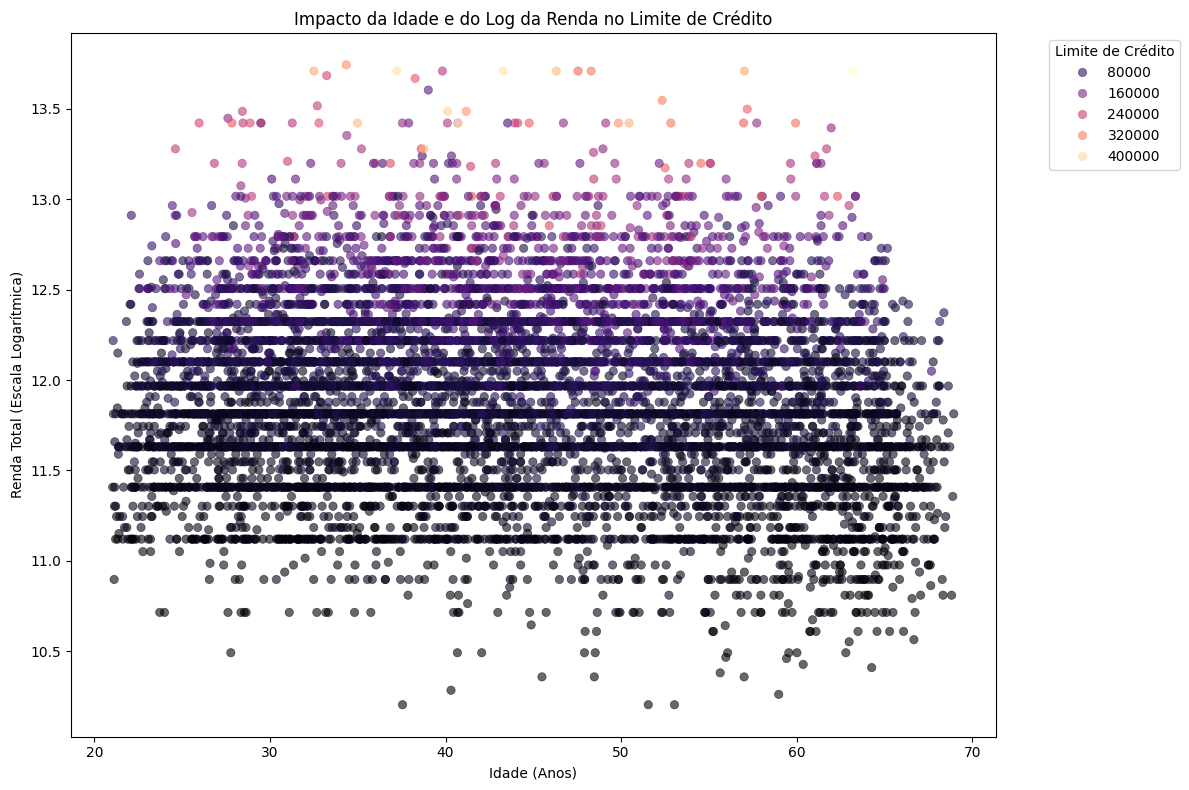

In [24]:
df_p = df.toPandas()

#! Ideia 3: Scatterplot de 3 Variáveis (Idade, Log Renda e Limite)
plt.figure(figsize=(12, 8))

# Converte dias para anos
df_p['IDADE_ANOS'] = df_p['DAYS_BIRTH'] / 365

# Aplica o Log na renda para estabilizar a variância
df_p['LOG_RENDA'] = np.log1p(df_p['AMT_INCOME_TOTAL'])

# Plota amostrando apenas 10% para o gráfico ficar legível e renderizar rápido
amostra = df_p.sample(frac=0.1, random_state=42)

scatter = sns.scatterplot(
    data=amostra, 
    x='IDADE_ANOS', 
    y='LOG_RENDA', 
    hue='TARGET_CREDIT_LIMIT', 
    palette='magma', # Paleta que vai do escuro (baixo limite) ao claro (alto limite)
    alpha=0.6,
    edgecolor=None
)

plt.title('Impacto da Idade e do Log da Renda no Limite de Crédito')
plt.xlabel('Idade (Anos)')
plt.ylabel('Renda Total (Escala Logarítmica)')

# Ajusta a legenda para não cobrir o gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Limite de Crédito')
plt.tight_layout()
plt.show()